# P03 — Explorando dados de sensores industriais

**Análise exploratória (EDA)** do dataset *Microsoft Azure Predictive Maintenance*.

**Objetivo:** entender um ano de telemetria de 100 máquinas industriais (5 tabelas relacionadas)
e verificar se há mudança detectável no sinal dos sensores **antes** de uma falha — o que
determina se manutenção preditiva é viável neste conjunto de dados.

> Dataset sintético, de uso didático. Não são dados de uma fábrica real.

## 1. Importações e configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

IMG = "../images"   # pasta onde as figuras usadas no README são salvas

def salvar(nome):
    plt.savefig(f"{IMG}/{nome}", dpi=120, bbox_inches="tight")

## 2. Carregamento dos dados

| Arquivo | Conteúdo | Chave |
|---|---|---|
| `PdM_telemetry.csv` | Leitura horária dos 4 sensores (`volt`, `rotate`, `pressure`, `vibration`) | `machineID` + `datetime` |
| `PdM_errors.csv` | Erros registrados (máquina segue operando) | `machineID` + `datetime` |
| `PdM_failures.csv` | Falhas de componente (parada + troca) | `machineID` + `datetime` |
| `PdM_maint.csv` | Trocas de componente (preventivas e corretivas) | `machineID` + `datetime` |
| `PdM_machines.csv` | Modelo e idade de cada máquina | `machineID` |

In [2]:
errors    = pd.read_csv("../data/PdM_errors.csv")
failures  = pd.read_csv("../data/PdM_failures.csv")
machines  = pd.read_csv("../data/PdM_machines.csv")
maint     = pd.read_csv("../data/PdM_maint.csv")
telemetry = pd.read_csv("../data/PdM_telemetry.csv")

## 3. Inspeção inicial

In [3]:
# Dimensões das 5 tabelas
print("Dimensões (linhas, colunas):")
for nome, df in [("telemetry", telemetry), ("errors", errors), ("failures", failures),
                 ("maint", maint), ("machines", machines)]:
    print(f"  {nome:<10} {df.shape}")

# Colunas, tipos e contagem de não-nulos das duas tabelas principais
# (a coluna datetime vem como texto e será convertida na seção 6)
telemetry.info()
machines.info()

# Primeiras linhas
display(telemetry.head())
display(machines.head())

Dimensões (linhas, colunas):
  telemetry  (876100, 6)
  errors     (3919, 3)
  failures   (761, 3)
  maint      (3286, 3)
  machines   (100, 3)
<class 'pandas.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   datetime   876100 non-null  str    
 1   machineID  876100 non-null  int64  
 2   volt       876100 non-null  float64
 3   rotate     876100 non-null  float64
 4   pressure   876100 non-null  float64
 5   vibration  876100 non-null  float64
dtypes: float64(4), int64(1), str(1)
memory usage: 40.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   machineID  100 non-null    int64
 1   model      100 non-null    str  
 2   age        100 non-null    int64
dtypes: int64(2), str(1)
memory usage: 2.5 KB


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2


## 4. Parque de máquinas

Caracterizar a frota antes de olhar os sinais: quantos modelos, como a idade se distribui,
se algum modelo é sistematicamente mais velho.

In [4]:
display(machines["model"].value_counts())
display(machines["age"].describe())
display(machines.groupby("model")["age"].describe())

model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64

count    100.000000
mean      11.330000
std        5.856974
min        0.000000
25%        6.750000
50%       12.000000
75%       16.000000
max       20.000000
Name: age, dtype: float64

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
model1,16.0,12.250000,5.385165,2.0,9.25,14.0,16.00,20.0
model2,17.0,12.764706,5.847322,2.0,10.00,14.0,18.00,20.0
model3,35.0,12.028571,5.607168,1.0,8.50,14.0,17.00,20.0
model4,32.0,9.343750,6.099230,0.0,4.00,9.5,14.25,20.0


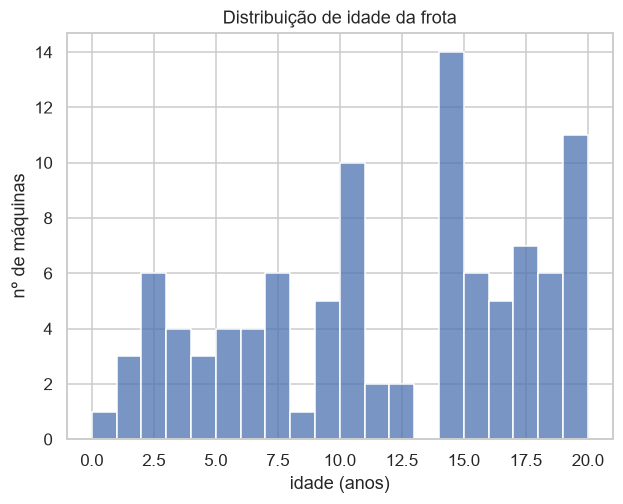

In [5]:
ax = sns.histplot(data=machines, x="age", bins=20)
ax.set(title="Distribuição de idade da frota", xlabel="idade (anos)", ylabel="nº de máquinas");

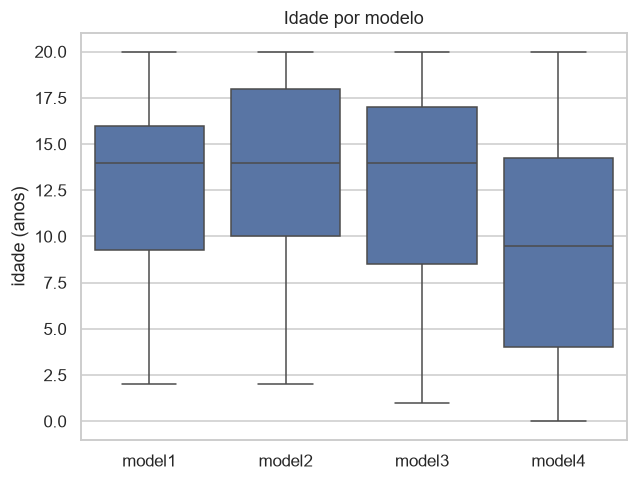

In [6]:
ordem = ["model1", "model2", "model3", "model4"]
ax = sns.boxplot(data=machines, x="model", y="age", order=ordem)
ax.set(title="Idade por modelo", xlabel="", ylabel="idade (anos)")
salvar("01_idade_por_modelo.png")

## 5. Distribuições e correlação dos sensores

Como cada sensor (`volt`, `rotate`, `pressure`, `vibration`) se comporta em condições
normais e como eles se relacionam entre si.

In [7]:
sensores = ["volt", "rotate", "pressure", "vibration"]
telemetry[sensores].describe()

,volt,rotate,pressure,vibration
count,876100.000000,876100.000000,876100.000000,876100.000000
mean,170.777736,446.605119,100.858668,40.385007
std,15.509114,52.673886,11.048679,5.370361
min,97.333604,138.432075,51.237106,14.877054
25%,160.304927,412.305714,93.498181,36.777299
50%,170.607338,447.558150,100.425559,40.237247
75%,181.004493,482.176600,107.555231,43.784938
max,255.124717,695.020984,185.951998,76.791072


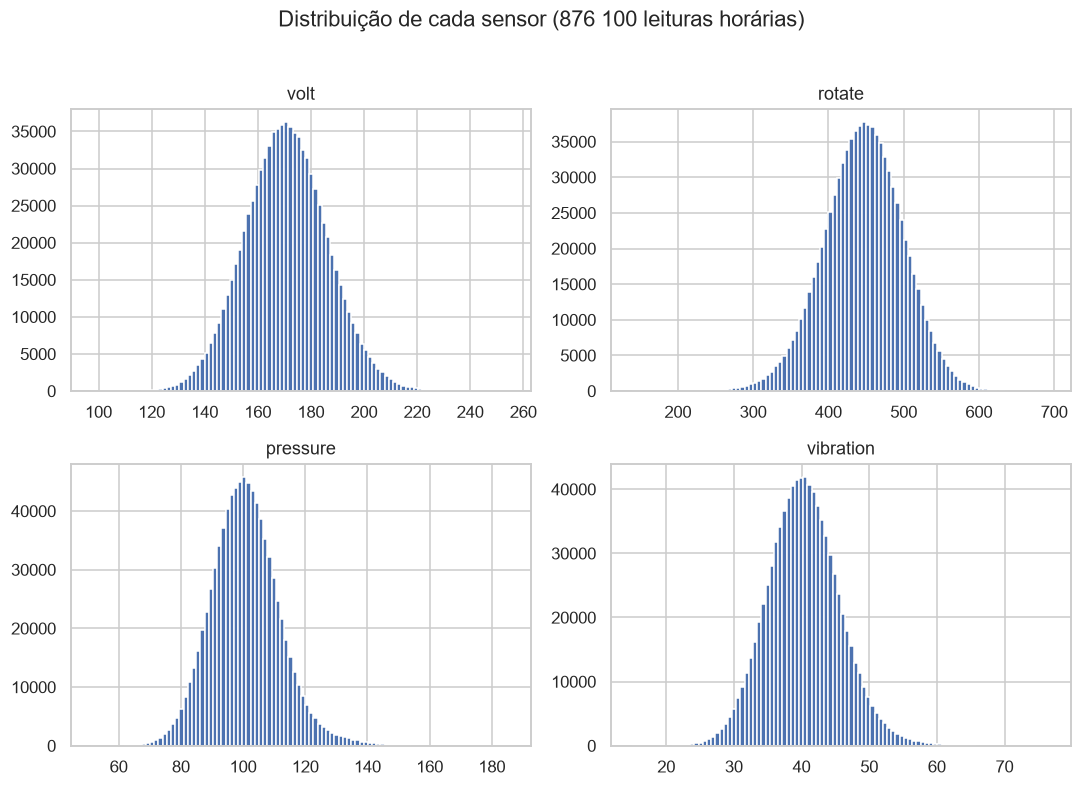

In [8]:
telemetry[sensores].hist(figsize=(10, 7), bins=100, layout=(2, 2))
plt.suptitle("Distribuição de cada sensor (876 100 leituras horárias)", y=1.02)
plt.tight_layout()
salvar("02_distribuicao_sensores.png")

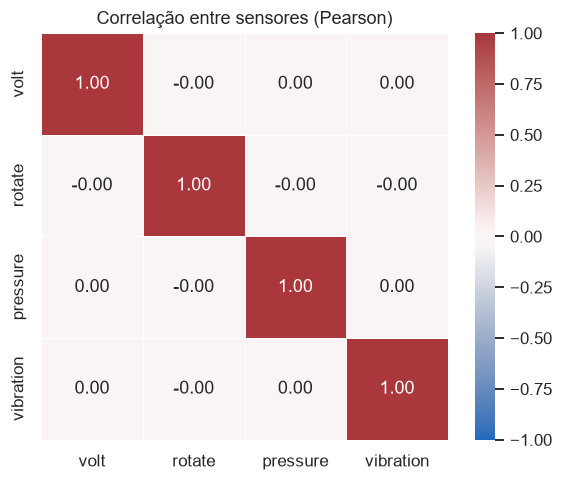

In [9]:
corr = telemetry[sensores].corr()
ax = sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
                 vmin=-1, vmax=1, square=True, linewidths=.5)
ax.set_title("Correlação entre sensores (Pearson)")
salvar("03_correlacao_sensores.png")

## 6. Série temporal de uma máquina

Converter `datetime` para data, recortar uma máquina e observar os 4 sensores ao longo
do tempo (nível, ruído, tendência).

In [10]:
telemetry["datetime"] = pd.to_datetime(telemetry["datetime"])
telemetry.info()

<class 'pandas.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   datetime   876100 non-null  datetime64[us]
 1   machineID  876100 non-null  int64         
 2   volt       876100 non-null  float64       
 3   rotate     876100 non-null  float64       
 4   pressure   876100 non-null  float64       
 5   vibration  876100 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 40.1 MB


In [11]:
m1 = telemetry[telemetry["machineID"] == 1].copy().sort_values("datetime")
m1.shape

(8761, 6)

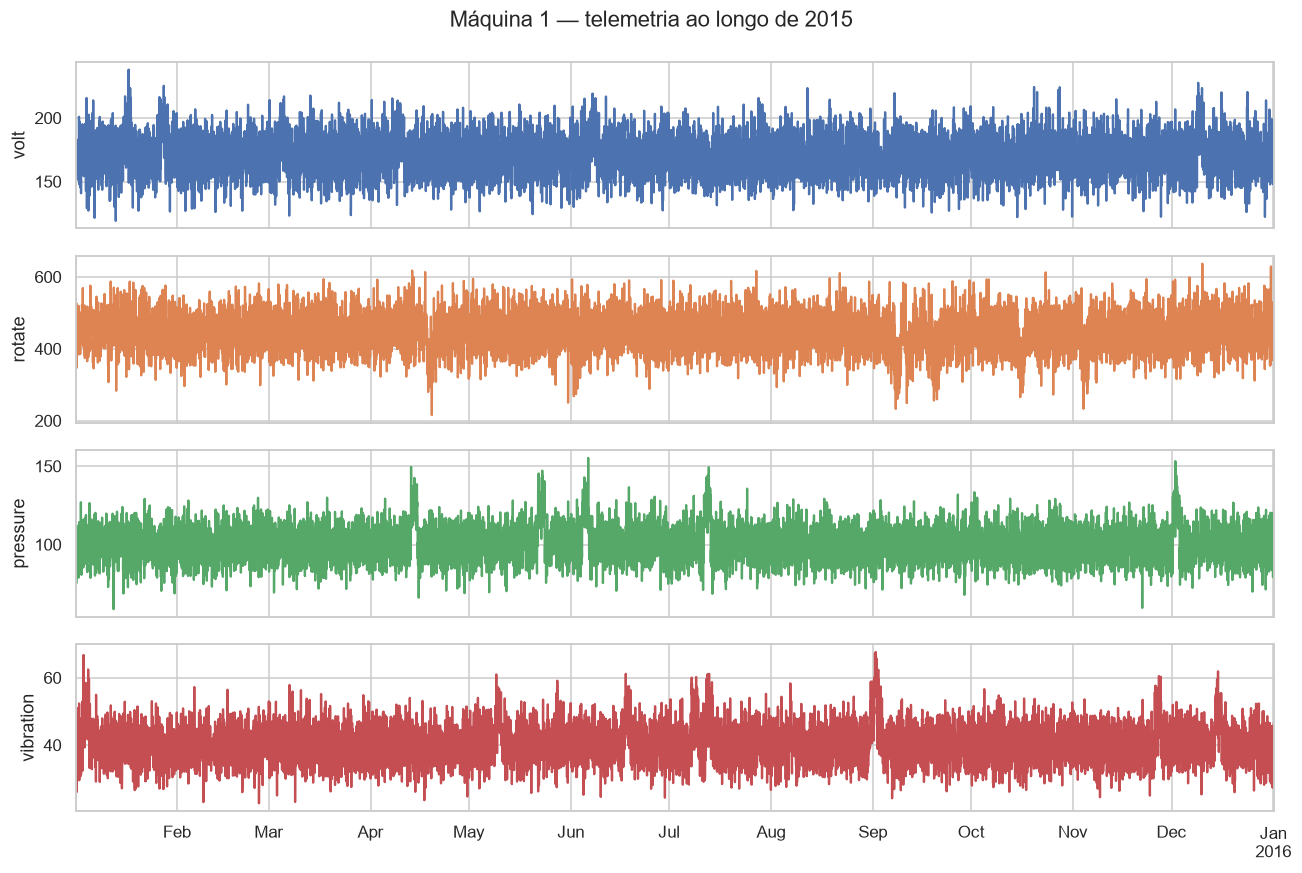

In [12]:
eixos = m1.plot(x="datetime", y=sensores, subplots=True, figsize=(12, 8), legend=False)
for ax, s in zip(eixos, sensores):
    ax.set_ylabel(s)
eixos[-1].set_xlabel("")
eixos[0].figure.suptitle("Máquina 1 — telemetria ao longo de 2015", y=0.99)
plt.tight_layout()
salvar("04_serie_temporal_maquina1.png")

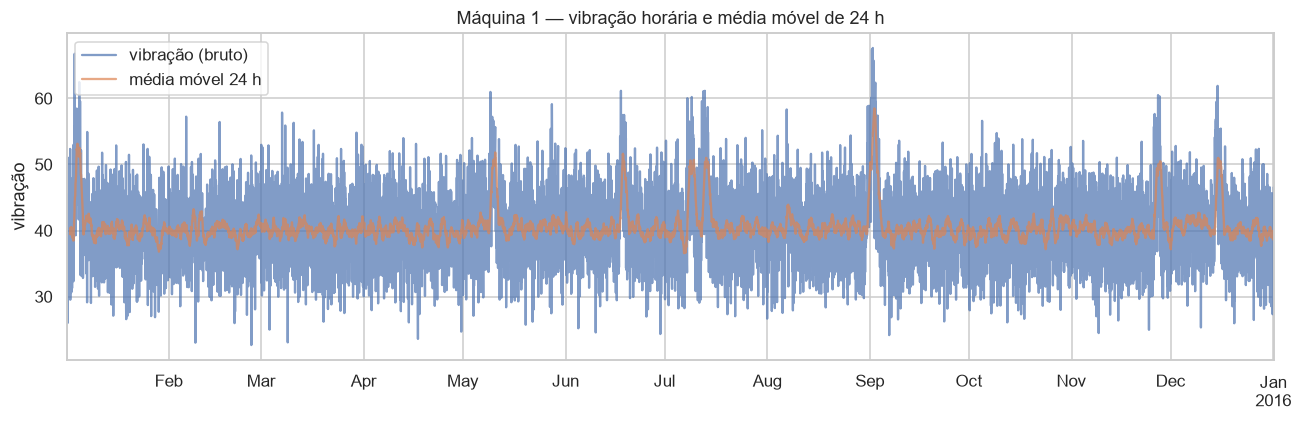

In [13]:
m1["vib_mm24"] = m1["vibration"].rolling(24).mean()
ax = m1.plot(x="datetime", y=["vibration", "vib_mm24"], figsize=(12, 4), alpha=0.7)
ax.set(title="Máquina 1 — vibração horária e média móvel de 24 h", xlabel="", ylabel="vibração")
ax.legend(["vibração (bruto)", "média móvel 24 h"])
plt.tight_layout()
salvar("05_vibracao_media_movel.png")

## 7. Erros, falhas e manutenção

Tipos e frequência de erros e falhas, taxa de falha por máquina e por modelo,
e o perfil da manutenção.

In [14]:
for df in (errors, failures, maint):
    df["datetime"] = pd.to_datetime(df["datetime"])

In [15]:
errors["errorID"].value_counts()

errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64

In [16]:
# erros por máquina: todas as 100 aparecem, distribuição parelha (~39/ano)
errors["machineID"].value_counts().describe()

count    100.000000
mean      39.190000
std        6.882411
min       22.000000
25%       35.000000
50%       39.000000
75%       43.000000
max       60.000000
Name: count, dtype: float64

In [17]:
failures["failure"].value_counts()

failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

In [18]:
# count = 98  ->  2 máquinas não tiveram nenhuma falha no ano
failures["machineID"].value_counts().describe()

count    98.000000
mean      7.765306
std       3.463509
min       2.000000
25%       5.000000
50%       7.000000
75%      10.000000
max      19.000000
Name: count, dtype: float64

In [19]:
n_maquinas = machines["machineID"].nunique()
taxa = len(failures) / n_maquinas
print(f"{len(failures)} falhas / {n_maquinas} máquinas / 1 ano = {taxa:.2f} falhas por máquina-ano")

761 falhas / 100 máquinas / 1 ano = 7.61 falhas por máquina-ano


In [20]:
# falhas por máquina-ano, por modelo (normalizado pelo nº de máquinas de cada modelo)
fm = failures.merge(machines, on="machineID")
falhas_por_modelo   = fm.groupby("model")["failure"].count()
maquinas_por_modelo = machines["model"].value_counts()
falhas_por_maquina  = (falhas_por_modelo / maquinas_por_modelo).sort_values()
falhas_por_maquina

model
model4     5.718750
model3     6.314286
model2     9.882353
model1    11.812500
dtype: float64

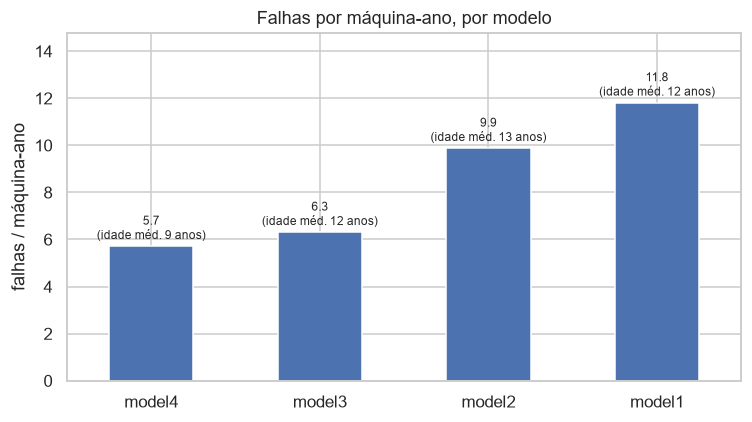

In [21]:
idade_media = machines.groupby("model")["age"].mean()
ax = falhas_por_maquina.plot(kind="bar", figsize=(7, 4), color="#4C72B0")
ax.set(title="Falhas por máquina-ano, por modelo", xlabel="", ylabel="falhas / máquina-ano")
ax.set_ylim(0, falhas_por_maquina.max() * 1.25)
ax.tick_params(axis="x", rotation=0)
for i, modelo in enumerate(falhas_por_maquina.index):
    ax.text(i, falhas_por_maquina[modelo] + 0.15,
            f"{falhas_por_maquina[modelo]:.1f}\n(idade méd. {idade_media[modelo]:.0f} anos)",
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
salvar("06_falhas_por_modelo.png")

In [22]:
maint["comp"].value_counts()

comp
comp2    863
comp4    811
comp3    808
comp1    804
Name: count, dtype: int64

**Volume de manutenção vs. falhas:** `maint` tem 3 286 registros contra 761 falhas. Como toda
falha gera uma troca, ~761 manutenções são corretivas e as outras **~2 500 (≈ 77 %) são
preventivas** — a frota opera sob um regime majoritariamente agendado, não reativo. As trocas
se distribuem de forma quase uniforme entre os quatro componentes, ou seja, não acompanham a
taxa de falha de cada um.

## 8. Sinais antes da falha

O coração do projeto: recortar a janela de telemetria nas horas anteriores a uma falha e
comparar com uma janela normal da mesma máquina; depois generalizar para todas as falhas.

In [23]:
failures[failures["machineID"] == 1]

,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4
5,2015-10-17 06:00:00,1,comp2
6,2015-12-16 06:00:00,1,comp4


In [24]:
t_falha = pd.Timestamp("2015-09-02 06:00:00")   # falha de comp4 na máquina 1
inicio  = t_falha - pd.Timedelta(hours=48)

m1 = telemetry[telemetry["machineID"] == 1].copy().sort_values("datetime")

In [25]:
janela_falha = m1[(m1["datetime"] >= inicio) & (m1["datetime"] <= t_falha)]
janela_falha.head()

,datetime,machineID,volt,rotate,pressure,vibration
5808,2015-08-31 06:00:00,1,207.324122,469.789032,101.489391,52.716433
5809,2015-08-31 07:00:00,1,180.008373,377.194231,88.373588,50.660131
5810,2015-08-31 08:00:00,1,183.370293,378.611833,99.523552,47.917584
5811,2015-08-31 09:00:00,1,195.959057,530.797870,97.047854,58.826930
5812,2015-08-31 10:00:00,1,176.316093,458.804642,100.837395,52.173623


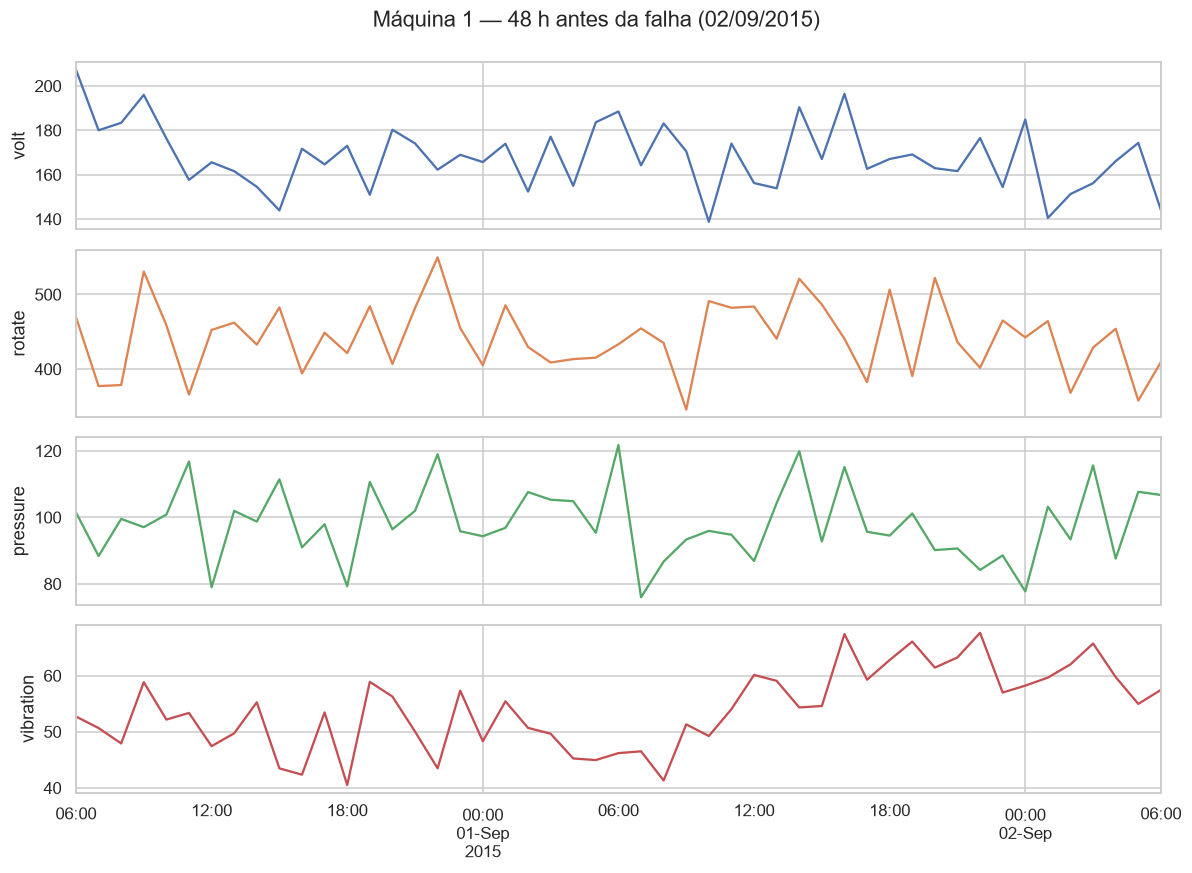

In [26]:
eixos = janela_falha.plot(x="datetime", y=sensores, subplots=True, figsize=(11, 8), legend=False)
for ax, s in zip(eixos, sensores):
    ax.set_ylabel(s)
eixos[-1].set_xlabel("")
eixos[0].figure.suptitle("Máquina 1 — 48 h antes da falha (02/09/2015)", y=0.99)
plt.tight_layout()
salvar("07_janela_pre_falha.png")

In [27]:
t_ref      = pd.Timestamp("2015-08-01 06:00:00")   # período calmo, sem falha por perto
inicio_ref = t_ref - pd.Timedelta(hours=48)
janela_normal = m1[(m1["datetime"] >= inicio_ref) & (m1["datetime"] <= t_ref)]

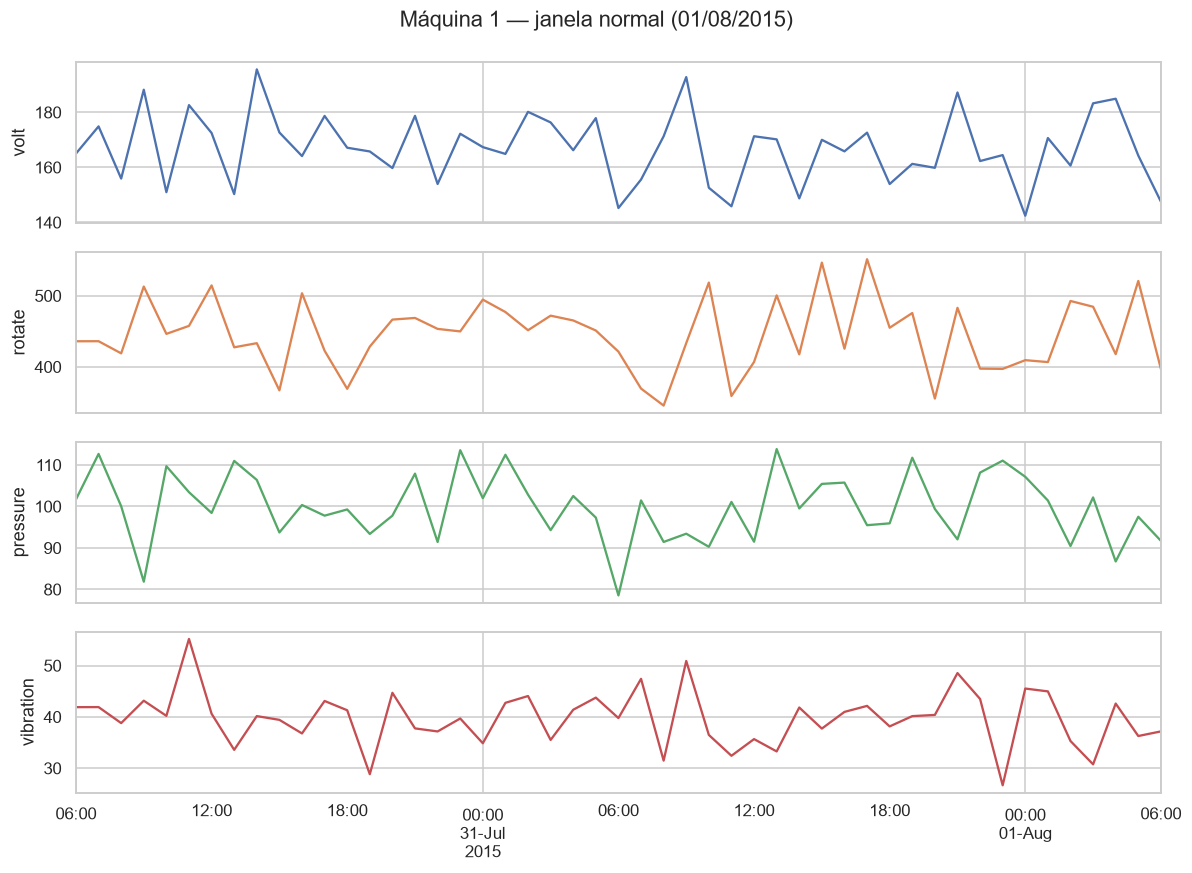

In [28]:
eixos = janela_normal.plot(x="datetime", y=sensores, subplots=True, figsize=(11, 8), legend=False)
for ax, s in zip(eixos, sensores):
    ax.set_ylabel(s)
eixos[-1].set_xlabel("")
eixos[0].figure.suptitle("Máquina 1 — janela normal (01/08/2015)", y=0.99)
plt.tight_layout()
salvar("08_janela_normal.png")

In [29]:
# marca cada leitura que cai nas 24 h anteriores a alguma falha
telemetry["pre_falha"] = False
for _, f in failures.iterrows():
    ini = f["datetime"] - pd.Timedelta(hours=24)
    mask = ((telemetry["machineID"] == f["machineID"])
            & (telemetry["datetime"] >= ini)
            & (telemetry["datetime"] < f["datetime"]))
    telemetry.loc[mask, "pre_falha"] = True

telemetry["pre_falha"].value_counts()

pre_falha
False    858916
True      17184
Name: count, dtype: int64

In [30]:
comparacao = telemetry.groupby("pre_falha")[sensores].mean()
comparacao

,volt,rotate,pressure,vibration
pre_falha,,,,
False,170.674551,447.166188,100.769813,40.337682
True,175.935276,418.560949,105.299940,42.750475


In [31]:
# deslocamento da média (pré-falha - normal) em unidades de desvio-padrão de cada sensor
desvios = telemetry[sensores].std()
((comparacao.loc[True] - comparacao.loc[False]) / desvios).round(2)

volt         0.34
rotate      -0.54
pressure     0.41
vibration    0.45
dtype: float64

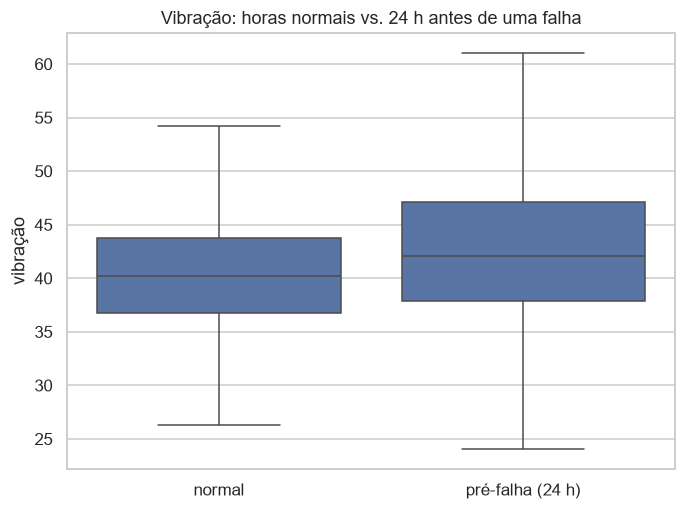

In [32]:
ax = sns.boxplot(data=telemetry, x="pre_falha", y="vibration", order=[False, True], showfliers=False)
ax.set(title="Vibração: horas normais vs. 24 h antes de uma falha", xlabel="", ylabel="vibração")
ax.set_xticks([0, 1])
ax.set_xticklabels(["normal", "pré-falha (24 h)"])
plt.tight_layout()
salvar("09_vibracao_por_grupo.png")

## 9. Conclusões e próximos passos

### O conjunto de dados
Um ano de telemetria horária de 100 máquinas industriais (876 100 leituras de 4 sensores),
acompanhado dos registros de erros, falhas de componente e manutenções. Dataset sintético,
de uso didático.

### Qualidade dos dados
- Nenhum valor nulo nas cinco tabelas.
- `datetime` vinha como texto e foi convertida para tipo data.
- Amostragem horária regular, sem lacunas aparentes.

### Parque de máquinas
- Quatro modelos; a idade da frota é quase uniforme entre 0 e 20 anos (média ≈ 11).
- `model4` é sistematicamente mais novo (idade média ≈ 9 anos) que os demais (≈ 12). É um
  fator de confusão (*confounding*) para qualquer comparação de confiabilidade por modelo.

### Comportamento dos sensores
- Os quatro sensores têm distribuição aproximadamente normal em torno de um valor de operação.
- A correlação linear entre sensores, medida sobre todo o período, é praticamente nula — cada
  sensor carrega informação independente.
- `pressure` e `vibration` apresentam uma leve cauda à direita.

### Erros, falhas e manutenção
- Taxa de falha global ≈ **7,6 falhas por máquina-ano**. `comp2` é o componente mais frágil
  (34 % das falhas).
- Falhas concentradas: 2 máquinas não falharam nenhuma vez no ano; outra falhou 19 vezes.
- Entre modelos de mesma idade, `model1` (11,8) e `model2` (9,9) falham bem mais por
  máquina-ano que `model3` (6,3) — efeito de modelo que a idade não explica. `model4` tem a
  menor taxa (5,7), mas é o mais novo, então o resultado não é conclusivo.
- ≈ 77 % das manutenções são preventivas (agendadas); o restante é reação a falha.

### Sinal antes da falha — resultado principal
- Nas 24 h que antecedem uma falha, os sensores se deslocam de forma coordenada:
  **vibração ↑, rotação ↓, pressão ↑, tensão ↑**, com magnitude da ordem de meio
  desvio-padrão na média da janela.
- No estudo de caso da máquina 1, a vibração sobe de ≈ 45 para ≈ 70 (~5 σ) nas últimas
  12–18 h antes da falha, enquanto numa janela de controle do mesmo equipamento permanece plana.
- O padrão se confirma agregando **716 janelas de falha** independentes, não só o caso isolado.

### Implicações
- **Manutenção preditiva é viável neste dataset**: existe degradação mensurável e antecipada
  à falha.
- Sugestões para o P08 (modelo preditivo): usar estatísticas móveis (média e desvio de 24 h)
  de `vibration` e `rotate` como variáveis de entrada; horizonte de previsão da ordem de
  12–24 h.
- Ressalvas: dataset sintético; confusão idade × modelo; correlações medidas apenas sobre o
  período completo.